# **Diabetes Prediction Classifier**

### We are classifying whether the paitent have diabetes or not based on the given dataset: "Pima Indians Diabetes Database"

*   0 represent Non-Diabetic
*   1 represent Diabetic



In [48]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### **Step2: Load & Exploratory Data Analysis**

In [49]:
# Loading the Dataset
path="/content/drive/MyDrive/my folder/diabetes.csv"
df=pd.read_csv(path)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [50]:
# It tells the no of rows & columns present in the dataset
df.shape

(768, 9)

In [51]:
# It shows the first 5 rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [52]:
# It shows the last 5 rows
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [53]:
# It gives the information about attributes(columns) datatype: int64,float64, object etc
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [54]:
# It gives statistical summary
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Exploratory Data Analysis**

In [55]:
# Checking missing values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [56]:
# Duplicate values
df.duplicated().sum()

np.int64(0)

In [57]:
# To see no of diabetic & non-diabetic
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


it means there are 500 non-diabetic & 268 diabetic

### Visualizing data through graphs/charts

/tmp/ipykernel_3185/3964918127.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set1')


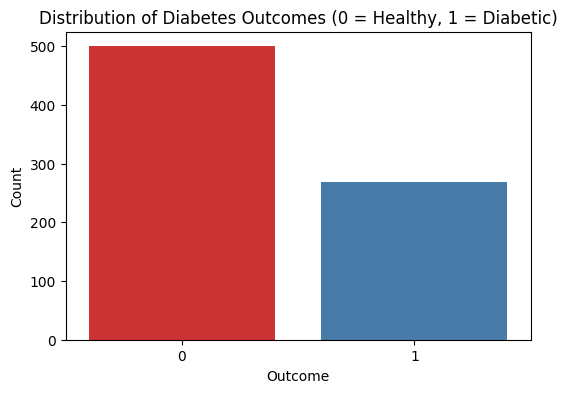

In [58]:
# Visualizing the Target Class Distribution (Outcome)
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='Set1')
plt.title('Distribution of Diabetes Outcomes (0 = Healthy, 1 = Diabetic)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

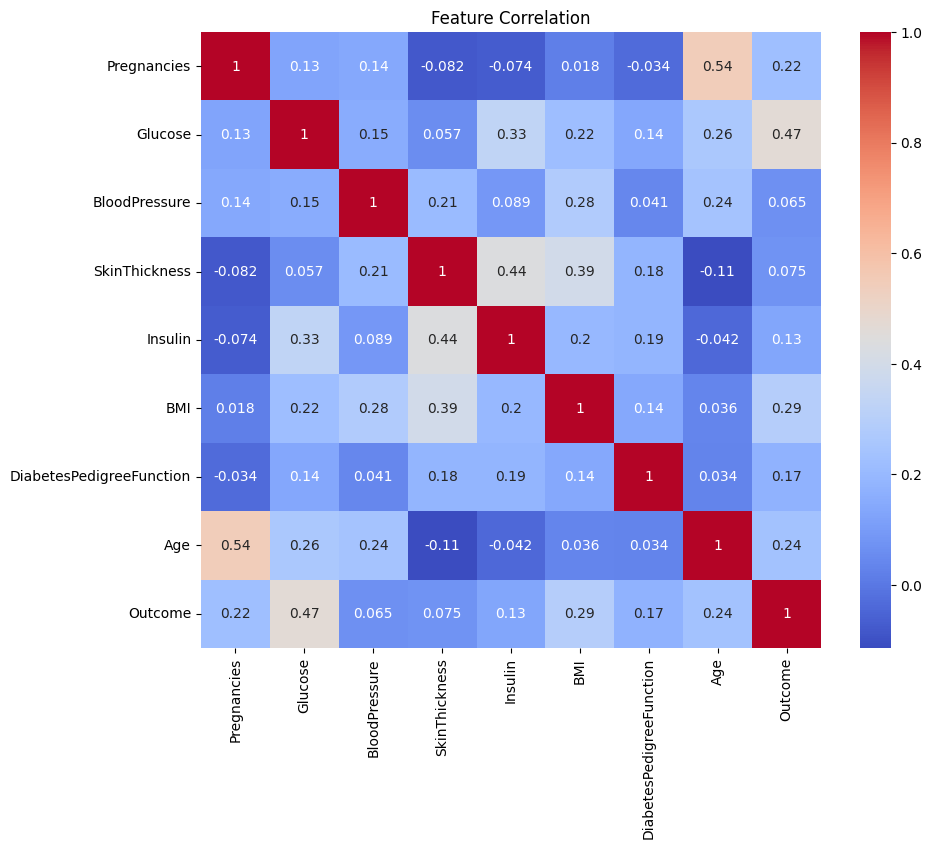

In [59]:
# Heatmap-- to see relation between features
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True,cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

A correlation heatmap shows how strongly pairs of features are related to each other. The numbers range from -1.0 to +1.0:

1. Close to +1.0 (Dark Red): Strong positive relationship. If one value goes up, the other goes up (e.g., as Age increases, Pregnancies generally increase).

2. Close to 0.0 (Light Blue/Grey): No real relationship between the features.

3. Close to -1.0 (Dark Blue): Inverse relationship. If one goes up, the other goes down.

So,

 1.**Glucose** has the highest correlation with the target variable (`Outcome`) at **0.47**. This indicates that plasma glucose concentration is the single most influential feature in our dataset for predicting whether a patient is diabetic.
   - **BMI (0.29)** and **Age (0.24)** follow as the next most significant factors.

2. **Strongest Feature Inter-Relationships:**
   - **Age vs. Pregnancies (0.54):** This is the strongest correlation in the entire dataset. It is a natural biological relationship—older patients in this dataset generally have a higher number of pregnancies.
   - **SkinThickness vs. Insulin (0.44) & BMI (0.39):** There is a noticeable positive relationship here. Higher BMI correlates with increased skinfold thickness and higher insulin levels, which aligns directly with clinical expectations for metabolic trends.

3. **Weakest Predictors:**
   - **BloodPressure (0.065)** and **SkinThickness (0.075)** show very low direct correlation scores with the final `Outcome`. This tells us that on their own, they don't strongly indicate diabetes, but they are still valuable when combined with other features in tree-based algorithms (Decision Trees and Random Forests).

In [60]:
# The Pima dataset encodes missing medical entries as 0 (e.g., Blood Pressure can't be 0).
# replace the invalid '0' values with NaN (Not a Number)
missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in missing_cols:
    df[col] = df[col].replace(0, np.nan)

# 2. Fill those NaN values with the median of each specific column
for col in missing_cols:
    column_median = df[col].median()
    df[col] = df[col].fillna(column_median)

In [61]:
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    zero_count = (df[col] == 0).sum()
    print(f" - {col}: {zero_count} zeros")

 - Glucose: 0 zeros
 - BloodPressure: 0 zeros
 - SkinThickness: 0 zeros
 - Insulin: 0 zeros
 - BMI: 0 zeros


### No scaling needed for Decision tree & Random Forest

### **Split the data into train & test**

In [62]:
# Split features (X) and target label (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [63]:
# Split data into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [64]:
print(X_train.shape)

(614, 8)


In [65]:
print(X_test.shape)

(154, 8)


# **Model Selection & training**

In [66]:
# Base Model: Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [67]:
# Ensemble Model: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

### **Evaluation**

In [70]:
# Decision Tree
dt_report = classification_report(y_test, y_pred_dt)
print(dt_report)

              precision    recall  f1-score   support

           0       0.84      0.79      0.81       100
           1       0.65      0.72      0.68        54

    accuracy                           0.77       154
   macro avg       0.75      0.76      0.75       154
weighted avg       0.77      0.77      0.77       154



Text(50.722222222222214, 0.5, 'True Label')

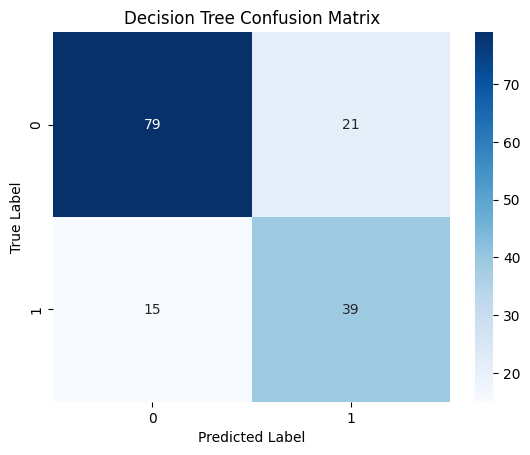

In [78]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True,cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

In [71]:
# Random Forest
rf_report = classification_report(y_test, y_pred_rf)
print(rf_report)

              precision    recall  f1-score   support

           0       0.77      0.85      0.81       100
           1       0.65      0.52      0.58        54

    accuracy                           0.73       154
   macro avg       0.71      0.68      0.69       154
weighted avg       0.73      0.73      0.73       154



Text(50.722222222222214, 0.5, 'True Label')

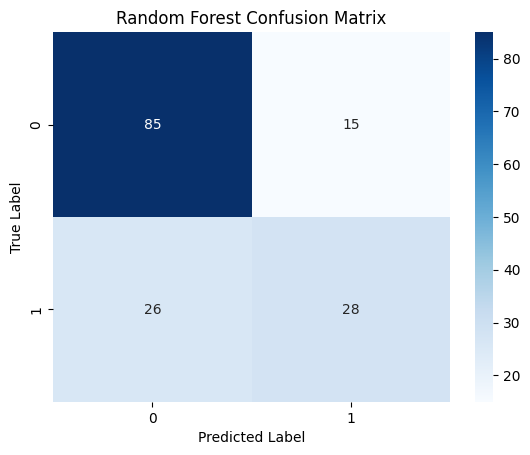

In [79]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True,cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

Precision: Out of all patients the model predicted as diabetic, how many were actually diabetic? (Higher precision means fewer false alarms).

Recall (Sensitivity): Out of all the actual diabetic patients in the test set, how many did the model manage to find? (Higher recall means fewer missed cases, which is critical in healthcare).

F1-Score: The perfect balance between Precision and Recall.